In [17]:
import os

ruta = "../data/processed/dataset_modelo.gpkg"
existe = os.path.exists(ruta)
tamaño = os.path.getsize(ruta) / 1024 if existe else 0

print(f"Archivo existe : {existe}")
print(f"Tamaño : {tamaño:.1f} KB")

# Si existe y pesa más de 50 KB, está bien guardado

Archivo existe : True
Tamaño : 420.0 KB


In [20]:
# Cargar dataset y preparar splits
import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib

gdf = gpd.read_file("../data/processed/dataset_modelo.gpkg")

feature_cols = [
    'twi_mean', 'twi_max', 'twi_std',
    'slope_mean', 'slope_max',
    'elev_mean', 'elev_min',
    'altura_cm', 'area_m2',
    'infra_cod', 'motivo_cod'
]

X = gdf[feature_cols].fillna(gdf[feature_cols].median())
y = gdf['riesgo_final']

# Codificar target como entero ordinal (respeta el orden de severidad)
orden = ['Bajo', 'Medio', 'Alto', 'Crítico']
le = LabelEncoder()
le.classes_ = np.array(orden)
y_enc = le.transform(y)

print("Dataset cargado:")
print(f"Muestras : {X.shape[0]}")
print(f"Features : {X.shape[1]}")
print(f"\nDistribución del target:")
for cls, n in zip(orden, np.bincount(y_enc)):
    print(f"{cls}: {n} ({n/len(y_enc)*100:.1f}%)")

Dataset cargado:
Muestras : 188
Features : 11

Distribución del target:
Bajo: 53 (28.2%)
Medio: 60 (31.9%)
Alto: 48 (25.5%)
Crítico: 27 (14.4%)


In [21]:
# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

resultados = cross_validate(
    rf, X, y_enc, cv=cv,
    scoring=['accuracy', 'f1_macro', 'f1_weighted'],
    return_train_score=True
)

print("-- Validación cruzada 5-fold --")
print(f"  Accuracy   test : {resultados['test_accuracy'].mean():.3f} "
      f"± {resultados['test_accuracy'].std():.3f}")
print(f"  F1 macro   test : {resultados['test_f1_macro'].mean():.3f} "
      f"± {resultados['test_f1_macro'].std():.3f}")
print(f"  F1 weighted test: {resultados['test_f1_weighted'].mean():.3f} "
      f"± {resultados['test_f1_weighted'].std():.3f}")
print(f"\nAccuracy train: {resultados['train_accuracy'].mean():.3f} "
      f"(diferencia con test: "
      f"{resultados['train_accuracy'].mean() - resultados['test_accuracy'].mean():.3f})")
print("\nNota: diferencia train-test > 0.15 indica sobreajuste.")

-- Validación cruzada 5-fold --
  Accuracy   test : 0.942 ± 0.031
  F1 macro   test : 0.919 ± 0.043
  F1 weighted test: 0.940 ± 0.032

Accuracy train: 1.000 (diferencia con test: 0.058)

Nota: diferencia train-test > 0.15 indica sobreajuste.


-- Reporte de clasificación (cross-val) --
              precision    recall  f1-score   support

        Bajo       1.00      1.00      1.00        53
       Medio       0.98      1.00      0.99        60
        Alto       0.86      0.92      0.89        48
     Crítico       0.87      0.74      0.80        27

    accuracy                           0.94       188
   macro avg       0.93      0.91      0.92       188
weighted avg       0.94      0.94      0.94       188



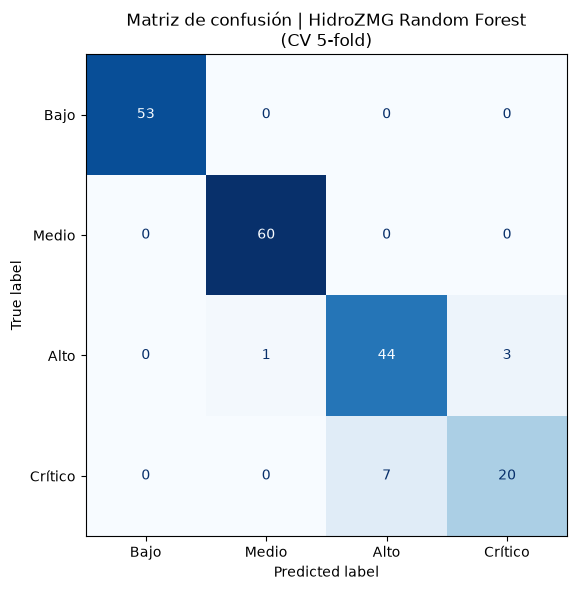

In [22]:
# Entrenar modelo final y matriz de confusión
rf.fit(X, y_enc)

from sklearn.model_selection import cross_val_predict
y_pred = cross_val_predict(rf, X, y_enc, cv=cv)

print("-- Reporte de clasificación (cross-val) --")
print(classification_report(y_enc, y_pred, target_names=orden))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_enc, y_pred,
    display_labels=orden,
    colorbar=False,
    cmap='Blues',
    ax=ax
)
ax.set_title("Matriz de confusión | HidroZMG Random Forest\n(CV 5-fold)")
plt.tight_layout()
plt.savefig("../data/processed/confusion_matrix.png", dpi=150)
plt.show()

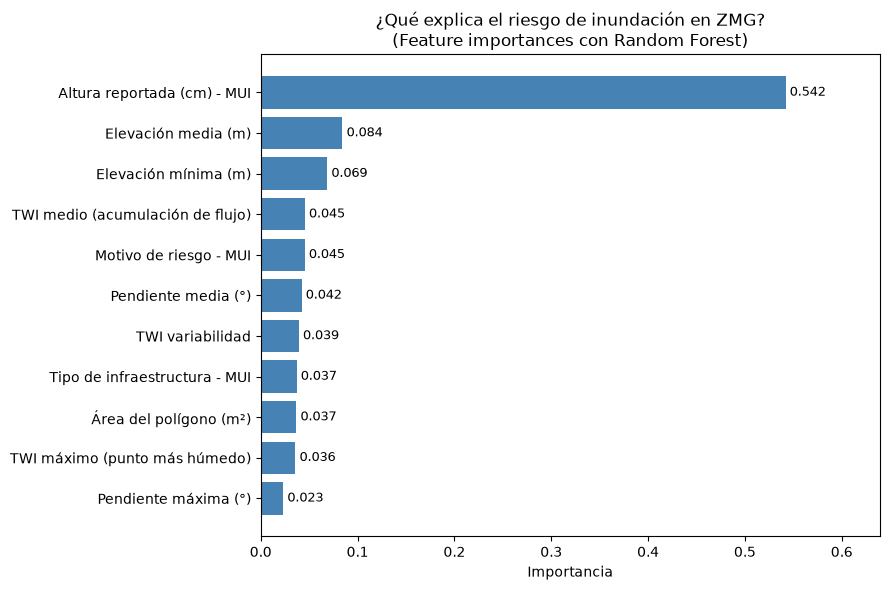


Top 3 features más importantes:
Altura reportada (cm) - MUI: 0.542
Elevación media (m): 0.084
Elevación mínima (m): 0.069


In [23]:
# Feature importances
importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)

# Nombres más legibles
nombres = {
    'twi_mean' : 'TWI medio (acumulación de flujo)',
    'twi_max' : 'TWI máximo (punto más húmedo)',
    'twi_std' : 'TWI variabilidad',
    'slope_mean' : 'Pendiente media (°)',
    'slope_max' : 'Pendiente máxima (°)',
    'elev_mean' : 'Elevación media (m)',
    'elev_min' : 'Elevación mínima (m)',
    'altura_cm' : 'Altura reportada (cm) - MUI',
    'area_m2' : 'Área del polígono (m²)',
    'infra_cod' : 'Tipo de infraestructura - MUI',
    'motivo_cod' : 'Motivo de riesgo - MUI'
}
importances.index = [nombres[i] for i in importances.index]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importances.index, importances.values, color='steelblue')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.set_xlabel("Importancia")
ax.set_title("¿Qué explica el riesgo de inundación en ZMG?\n(Feature importances con Random Forest)")
ax.set_xlim(0, importances.max() * 1.18)
plt.tight_layout()
plt.savefig("../data/processed/feature_importances.png", dpi=150)
plt.show()

print("\nTop 3 features más importantes:")
for nombre, val in importances.sort_values(ascending=False).head(3).items():
    print(f"{nombre}: {val:.3f}")

In [8]:
# Guardar modelo entrenado
import joblib, os
os.makedirs("../app/model", exist_ok=True)

joblib.dump(rf, "../app/model/random_forest.pkl")
joblib.dump(le, "../app/model/label_encoder.pkl")
joblib.dump(feature_cols, "../app/model/feature_cols.pkl")

# Guardar predicciones en el GeoDataFrame para la app
gdf['riesgo_predicho'] = le.inverse_transform(
    cross_val_predict(rf, X, y_enc, cv=cv)
)
gdf['riesgo_prob_critico'] = rf.predict_proba(X)[:, orden.index('Crítico')]
gdf.to_file("../data/processed/predicciones_modelo.gpkg", driver="GPKG")

print("Modelo guardado en app/model/")
print("Predicciones guardadas en predicciones_modelo.gpkg")
print("\nArchivos del modelo:")
for f in os.listdir("../app/model"):
    print(f"{f}")

Modelo guardado en app/model/
Predicciones guardadas en predicciones_modelo.gpkg

Archivos del modelo:
feature_cols.pkl
label_encoder.pkl
random_forest.pkl


Rebuild del modelo dado el sesgo en la altura reportada

-- Modelo v2 (Sin altura) --
Accuracy test : 0.463 ± 0.044
F1 macro test : 0.443 ± 0.047
F1 weighted test: 0.455 ± 0.040
Accuracy train: 0.844 (diferencia: 0.381)

-- Reporte de clasificación --
              precision    recall  f1-score   support

        Bajo       0.57      0.70      0.63        53
       Medio       0.49      0.42      0.45        60
        Alto       0.36      0.31      0.33        48
     Crítico       0.33      0.37      0.35        27

    accuracy                           0.46       188
   macro avg       0.44      0.45      0.44       188
weighted avg       0.46      0.46      0.46       188



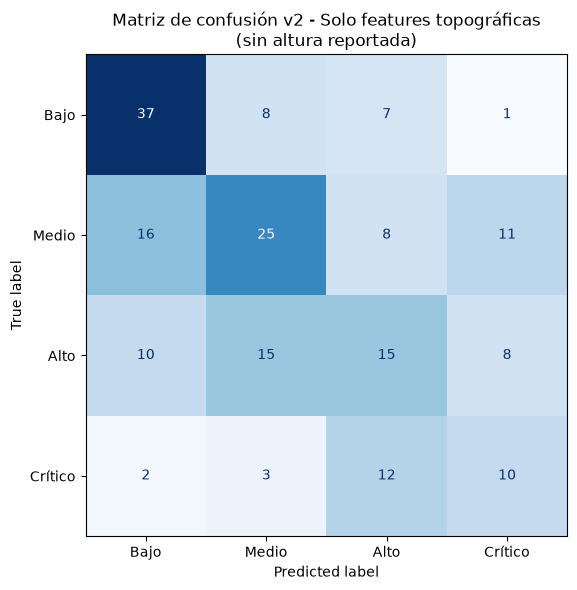

In [24]:
# Features limpias (sin altura_cm ni motivo_cod)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Features SOLO topográficas e infraestructura (sin altura_cm y sin motivo_cod)
feature_cols_v2 = [
    'twi_mean', 'twi_max', 'twi_std',
    'slope_mean', 'slope_max',
    'elev_mean', 'elev_min',
    'area_m2',
    'infra_cod' 
]

X2 = gdf[feature_cols_v2].fillna(gdf[feature_cols_v2].median())

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

res2 = cross_validate(
    rf2, X2, y_enc, cv=cv,
    scoring=['accuracy', 'f1_macro', 'f1_weighted'],
    return_train_score=True
)

print("-- Modelo v2 (Sin altura) --")
print(f"Accuracy test : {res2['test_accuracy'].mean():.3f} "
      f"± {res2['test_accuracy'].std():.3f}")
print(f"F1 macro test : {res2['test_f1_macro'].mean():.3f} "
      f"± {res2['test_f1_macro'].std():.3f}")
print(f"F1 weighted test: {res2['test_f1_weighted'].mean():.3f} "
      f"± {res2['test_f1_weighted'].std():.3f}")
print(f"Accuracy train: {res2['train_accuracy'].mean():.3f} "
      f"(diferencia: {res2['train_accuracy'].mean()-res2['test_accuracy'].mean():.3f})")

print("\n-- Reporte de clasificación --")
y_pred2 = cross_val_predict(rf2, X2, y_enc, cv=cv)
print(classification_report(y_enc, y_pred2, target_names=orden))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_enc, y_pred2,
    display_labels=orden,
    colorbar=False, cmap='Blues', ax=ax
)
ax.set_title("Matriz de confusión v2 - Solo features topográficas\n(sin altura reportada)")
plt.tight_layout()
plt.savefig("../data/processed/confusion_matrix_v2.png", dpi=150)
plt.show()

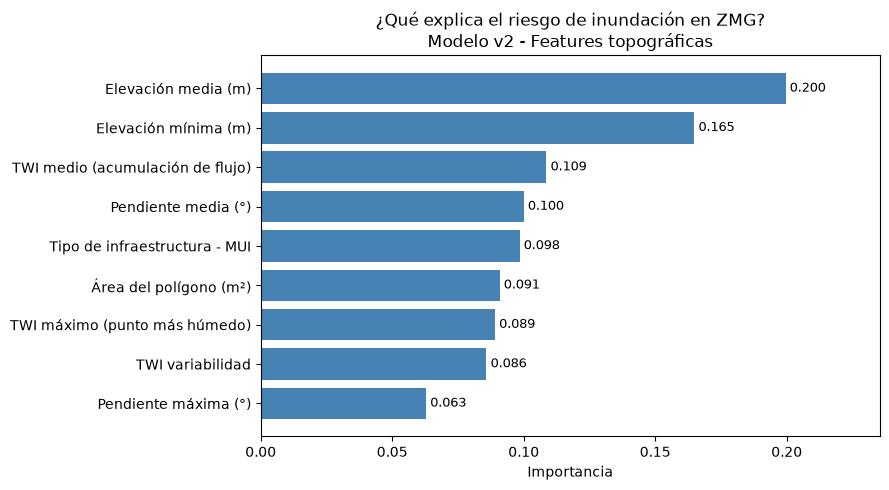

In [27]:
# Feature importances v2
rf2.fit(X2, y_enc)

nombres_v2 = {
    'twi_mean': 'TWI medio (acumulación de flujo)',
    'twi_max': 'TWI máximo (punto más húmedo)',
    'twi_std': 'TWI variabilidad',
    'slope_mean': 'Pendiente media (°)',
    'slope_max': 'Pendiente máxima (°)',
    'elev_mean': 'Elevación media (m)',
    'elev_min': 'Elevación mínima (m)',
    'area_m2': 'Área del polígono (m²)',
    'infra_cod': 'Tipo de infraestructura - MUI'
}

imp2 = pd.Series(rf2.feature_importances_, index=feature_cols_v2)
imp2.index = [nombres_v2[i] for i in imp2.index]
imp2 = imp2.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(imp2.index, imp2.values, color='steelblue')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.set_xlabel("Importancia")
ax.set_title("¿Qué explica el riesgo de inundación en ZMG?\nModelo v2 - Features topográficas")
ax.set_xlim(0, imp2.max() * 1.18)
plt.tight_layout()
plt.savefig("../data/processed/feature_importances_v2.png", dpi=150)
plt.show()

In [28]:
# Guardar modelo v2 (reemplaza al anterior)
import joblib, os

rf2.fit(X2, y_enc)

joblib.dump(rf2, "../app/model/random_forest.pkl")
joblib.dump(le, "../app/model/label_encoder.pkl")
joblib.dump(feature_cols_v2, "../app/model/feature_cols.pkl")

gdf2 = gpd.read_file("../data/processed/dataset_modelo.gpkg")
X2_full = gdf2[feature_cols_v2].fillna(gdf2[feature_cols_v2].median())
gdf2['riesgo_predicho'] = le.inverse_transform(rf2.predict(X2_full))
gdf2['prob_critico'] = rf2.predict_proba(X2_full)[:, orden.index('Crítico')]
gdf2['prob_alto'] = rf2.predict_proba(X2_full)[:, orden.index('Alto')]

gdf2.to_file("../data/processed/predicciones_modelo_v2.gpkg", driver="GPKG")
print("Modelo v2 guardado")
print("Features del modelo final:", feature_cols_v2)

Modelo v2 guardado
Features del modelo final: ['twi_mean', 'twi_max', 'twi_std', 'slope_mean', 'slope_max', 'elev_mean', 'elev_min', 'area_m2', 'infra_cod']


Distribución binaria:
Tolerable (bajo + medio): 113
Significativo (alto + crítico): 75

-- Modelo binario | Riesgo significativo vs tolerable --
Accuracy test: 0.670 ± 0.067
F1 test: 0.590 ± 0.078
ROC-AUC test: 0.761 ± 0.071
Accuracy train: 0.899 (diferencia: 0.229)

-- Reporte de clasificación --
                                precision    recall  f1-score   support

      Tolerable (bajo + medio)       0.73      0.72      0.72       113
Significativo (alto + crítico)       0.58      0.60      0.59        75

                      accuracy                           0.67       188
                     macro avg       0.66      0.66      0.66       188
                  weighted avg       0.67      0.67      0.67       188



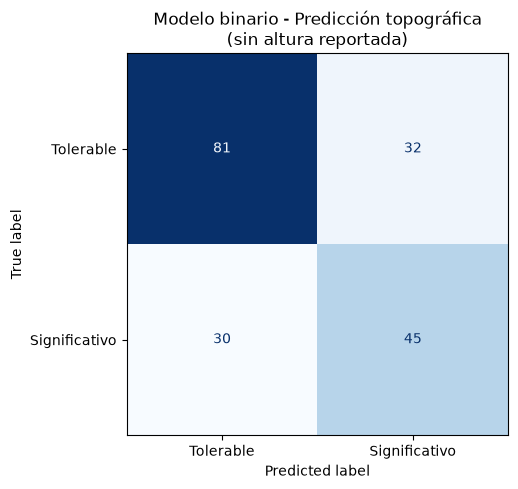

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Target binario: 0 = riesgo tolerable, 1 = riesgo significativo
y_bin = (y_enc >= 2).astype(int)  # Alto=2, Crítico=3 → clase 1
print("Distribución binaria:")
print(f"Tolerable (bajo + medio): {(y_bin==0).sum()}")
print(f"Significativo (alto + crítico): {(y_bin==1).sum()}")

cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf3 = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

res3 = cross_validate(
    rf3, X2, y_bin, cv=cv,
    scoring=['accuracy', 'f1', 'roc_auc'],
    return_train_score=True
)

print("\n-- Modelo binario | Riesgo significativo vs tolerable --")
print(f"Accuracy test: {res3['test_accuracy'].mean():.3f} "
      f"± {res3['test_accuracy'].std():.3f}")
print(f"F1 test: {res3['test_f1'].mean():.3f} "
      f"± {res3['test_f1'].std():.3f}")
print(f"ROC-AUC test: {res3['test_roc_auc'].mean():.3f} "
      f"± {res3['test_roc_auc'].std():.3f}")
print(f"Accuracy train: {res3['train_accuracy'].mean():.3f} "
      f"(diferencia: {res3['train_accuracy'].mean()-res3['test_accuracy'].mean():.3f})")

y_pred3 = cross_val_predict(rf3, X2, y_bin, cv=cv)
print("\n-- Reporte de clasificación --")
print(classification_report(y_bin, y_pred3,
      target_names=['Tolerable (bajo + medio)', 'Significativo (alto + crítico)']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_bin, y_pred3,
    display_labels=['Tolerable', 'Significativo'],
    colorbar=False, cmap='Blues', ax=ax
)
ax.set_title("Modelo binario - Predicción topográfica\n(sin altura reportada)")
plt.tight_layout()
plt.savefig("../data/processed/confusion_matrix_binario.png", dpi=150)
plt.show()

In [33]:
# Guardar ambos modelos para la app
import joblib, os

# Modelo 4 clases (para explicar el dataset MUI conocido)
rf2.fit(X2, y_enc)
joblib.dump(rf2, "../app/model/rf_4clases.pkl")
joblib.dump(le, "../app/model/label_encoder.pkl")

# Modelo binario (para predecir en sitios nuevos)
rf3.fit(X2, y_bin)
joblib.dump(rf3, "../app/model/rf_binario.pkl")
joblib.dump(feature_cols_v2, "../app/model/feature_cols.pkl")

# Predicciones en el dataset original
gdf3 = gpd.read_file("../data/processed/dataset_modelo.gpkg")
X3 = gdf3[feature_cols_v2].fillna(gdf3[feature_cols_v2].median())

gdf3['riesgo_predicho_4c'] = le.inverse_transform(rf2.predict(X3))
gdf3['riesgo_binario'] = rf3.predict(X3)
gdf3['prob_significativo'] = rf3.predict_proba(X3)[:, 1]

gdf3.to_file("../data/processed/predicciones_modelo.gpkg", driver="GPKG")
print("Modelos guardados:")
for f in os.listdir("../app/model"):
    print(f"  {f}")

Modelos guardados:
  feature_cols.pkl
  label_encoder.pkl
  random_forest.pkl
  rf_4clases.pkl
  rf_binario.pkl


In [40]:
# Diagnóstico de rutas antes de tocar la app
import os, joblib
import geopandas as gpd

base = "../"  # ajusta si ejecutas desde otra carpeta

archivos = {
    "GeoPackage predicciones" : base + "data/processed/predicciones_modelo.gpkg",
    "Modelo RF binario" : base + "app/model/rf_binario.pkl",
    "Modelo RF 4 clases" : base + "app/model/rf_4clases.pkl",
    "Label encoder" : base + "app/model/label_encoder.pkl",
    "Feature cols" : base + "app/model/feature_cols.pkl",
}

for nombre, ruta in archivos.items():
    existe = os.path.exists(ruta)
    tam    = f"{os.path.getsize(ruta)/1024:.1f} KB" if existe else "—"
    print(f"{'✓' if existe else '✗'}  {nombre} {tam}")

# Si el GPKG existe, ver columnas
gpkg = base + "data/processed/predicciones_modelo.gpkg"
if os.path.exists(gpkg):
    gdf = gpd.read_file(gpkg, ignore_geometry=True)
    print(f"\nColumnas en predicciones_modelo.gpkg:")
    print(gdf.columns.tolist())
    print(f"\nriesgo_final: {gdf['riesgo_final'].value_counts().to_dict() if 'riesgo_final' in gdf.columns else 'NO EXISTE'}")
    print(f"infra_norm  : {'existe' if 'infra_norm' in gdf.columns else 'NO EXISTE'}")

✓  GeoPackage predicciones 424.0 KB
✓  Modelo RF binario 804.7 KB
✓  Modelo RF 4 clases 1300.2 KB
✓  Label encoder 0.4 KB
✓  Feature cols 0.1 KB

Columnas en predicciones_modelo.gpkg:
['nombre', 'motivo_norm', 'infra_norm', 'altura_cm', 'riesgo', 'intervencion', 'descripcion', 'area_captacion_est_m2', 'cobeneficios', 'area_m2', 'riesgo_final', 'twi_max', 'twi_mean', 'twi_std', 'slope_max', 'slope_mean', 'elev_min', 'elev_mean', 'infra_cod', 'motivo_cod', 'riesgo_predicho_4c', 'riesgo_binario', 'prob_significativo']

riesgo_final: {'Medio': 60, 'Bajo': 53, 'Alto': 48, 'Crítico': 27}
infra_norm  : existe
